# Dataset analysis

## About the dataset

The dataset is a collection of **posts**, each with text content and two pieces of metadata: a **category** and a **publication date**. That shape lets us look not only at what the posts say, but also at how they are spread over time and across topics.

The text needs preprocessing — stop-word removal, lemmatization and possibly sentiment analysis. The metadata (`category` and `date`) makes it possible to study publication dynamics and the popularity of individual topics. A deeper EDA should check the **category balance** (is there class imbalance?) and the **dependency of publishing activity on time** (is there seasonality or a trend?).

Any other hidden traits of the data — missing metadata, duplicated posts — should be taken into account as well.

In [36]:
!pip install pandas matplotlib seaborn scikit-learn umap-learn spacy nltk sentence-transformers hdbscan colorama
!python -m spacy download ru_core_news_sm


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 35.4 MB/s eta 0:00:005 MB/s eta 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')


In [37]:
import re
import math
import warnings
from collections import Counter

import pandas as pd
from scipy.stats import kruskal
import spacy
import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    TfidfVectorizer, 
    CountVectorizer
)
from umap.umap_ import UMAP
from sklearn.manifold import TSNE

from sentence_transformers import SentenceTransformer

warnings.simplefilter(action='ignore', category=FutureWarning)

### Size and structure

In [38]:
df = pd.read_csv('all_channel_posts.csv', parse_dates=['date'])
df.head()

,message_id,sender_id,text,date,channel,category
0,126168,-1001754252633,⚡️Военнослужащие ВС Сирии **взяли под контроль...,2024-12-04 08:57:11+00:00,Топор Live,political
1,126166,-1001754252633,⚡️Ученики новосибирской школы **баррикадируют ...,2024-12-04 08:51:11+00:00,Топор Live,personal
2,126165,-1001754252633,⚡️Германия не исключает **введения своих мирот...,2024-12-04 08:45:06+00:00,Топор Live,political
3,126164,-1001754252633,"Доллар упал ниже 104₽, евро — ниже 110.\n\n[📈Т...",2024-12-04 08:35:11+00:00,Топор Live,finances
4,126163,-1001754252633,⚡️Учения ОДКБ в 2025 году пройдут в **Беларуси...,2024-12-04 08:28:45+00:00,Топор Live,political


In [39]:
print(f"Dataset size: {len(df)} posts")
print(f"Columns: {df.columns.tolist()}")
df.info()

Размер датасета: 22099 постов
Колонки: ['message_id', 'sender_id', 'text', 'date', 'channel', 'category']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   message_id  22099 non-null  int64              
 1   sender_id   22099 non-null  int64              
 2   text        22099 non-null  object             
 3   date        22099 non-null  datetime64[ns, UTC]
 4   channel     22099 non-null  object             
 5   category    22099 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(3)
memory usage: 1.0+ MB


The dataset holds **22,099 posts** and has a clear structure with no gaps — all 6 columns are fully populated. The key fields are:
- `text` (the main content for NLP analysis),
- `date` (a timestamp of type *datetime64[ns, UTC]* for studying publication dynamics),
- `category` (the categorical label for topic classification).

The technical columns `message_id` and `sender_id` (*int64*) identify records and authors, while `channel` (*object*) names the source of the post.

The volume is enough to find statistically significant patterns, though working with the texts may call for dimensionality reduction (TF-IDF or embeddings, for example).

The data types are the expected ones: *datetime64[ns, UTC]* for dates, *int64* for identifiers and *object* for the text and categorical fields. Nothing has to be cleaned up before the analysis can start.

Working with the texts will require preprocessing: normalization (stemming/lemmatization), stop-word removal and possibly vectorization (TF-IDF, Word2Vec). The volume supports statistically significant conclusions, but building ML models may require balancing the categories.

### Data quality

In [40]:
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nFull duplicates: {df.duplicated().sum()}")
print(f"Duplicated texts: {df['text'].duplicated().sum()}")
print(f"Duplicated texts with categories: {df.duplicated(subset=['text', 'category']).sum()}")

Пропуски в данных:
message_id    0
sender_id     0
text          0
date          0
channel       0
category      0
dtype: int64

Полные дубликаты: 0
Дубликаты текста: 772
Дубликаты текста с категориями: 740


The dataset is in good shape — every column is fully populated, so the substantive analysis can start right away. Text duplicates did turn up, however: 772 fully identical messages and 740 cases where both the text and the category match.

Those duplicates are a problem. Keeping every copy gives a machine learning model a skewed picture of how important the repeated messages are. It matters most for frequency-based text methods, where duplicates automatically carry extra weight.

**Recommended actions:**
- Drop the full text duplicates (772 records) — critical for NLP analysis
- Look at the duplicated texts with different categories (32 cases) — these may be labelling errors
- Find out where the duplication comes from (automatic generation, cross-posting, technical glitches)

In [41]:
df = df.drop_duplicates(subset=['text'])
df = df[df['category'] != 'other']
df = df.reset_index(drop=True)

In [42]:
categories = df['category'].unique()
n_categories = len(categories)

cols = 2
rows = math.ceil(n_categories / cols)

### Category distribution

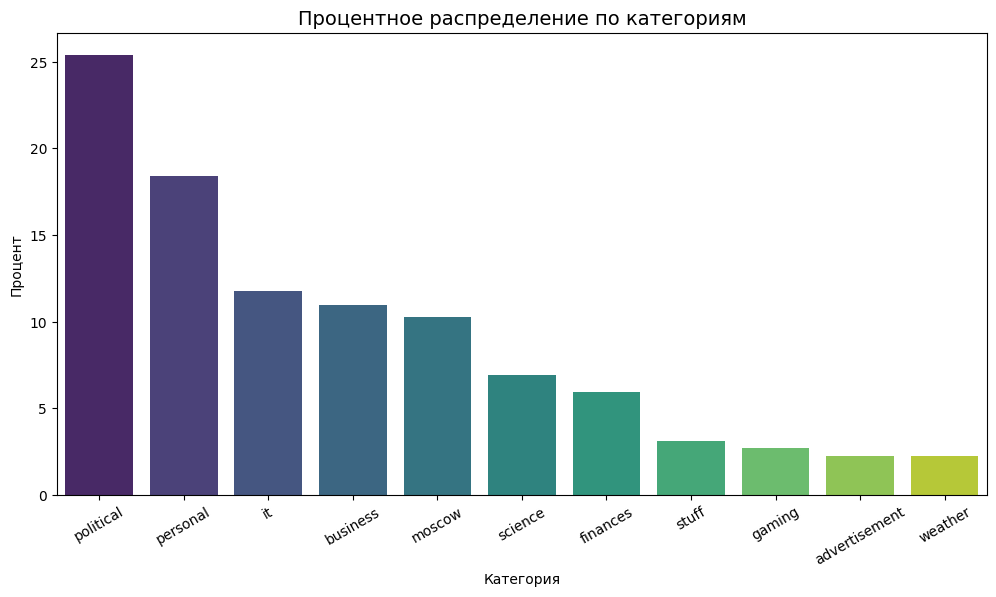

In [43]:
category_percent = df['category'].value_counts(normalize=True).sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=category_percent.index, y=category_percent.values, palette='viridis')
plt.title('Category distribution, percent', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Percent')
plt.xticks(rotation=30)
plt.show()

The category distribution shows a considerable class imbalance. The "political" category, for instance, makes up more than 20% of all posts, while "advertisement" stays under 2.5%. A skew like that has a real effect on future classification models, since the algorithms will tend to predict the dominant class to optimise accuracy.

**How to deal with it:**
- Use a stratified split (stratify).
- Judge the model by F1 rather than accuracy.
- Apply class weighting or resampling.

### Text length

Средняя длина: 54.7 слов
Медианная длина: 42.0 слов


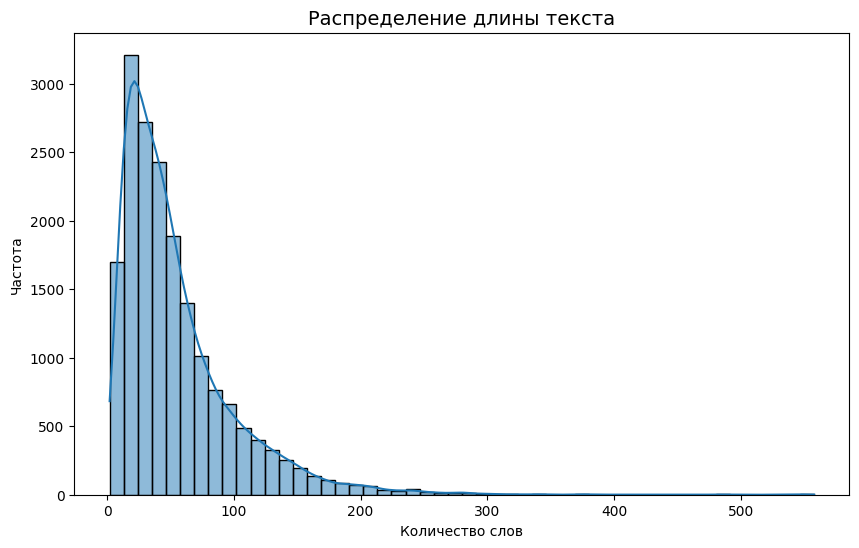

In [44]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
print(f"Mean length: {df['text_length'].mean():.1f} words")
print(f"Median length: {df['text_length'].median()} words")

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Text length distribution', fontsize=14)
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

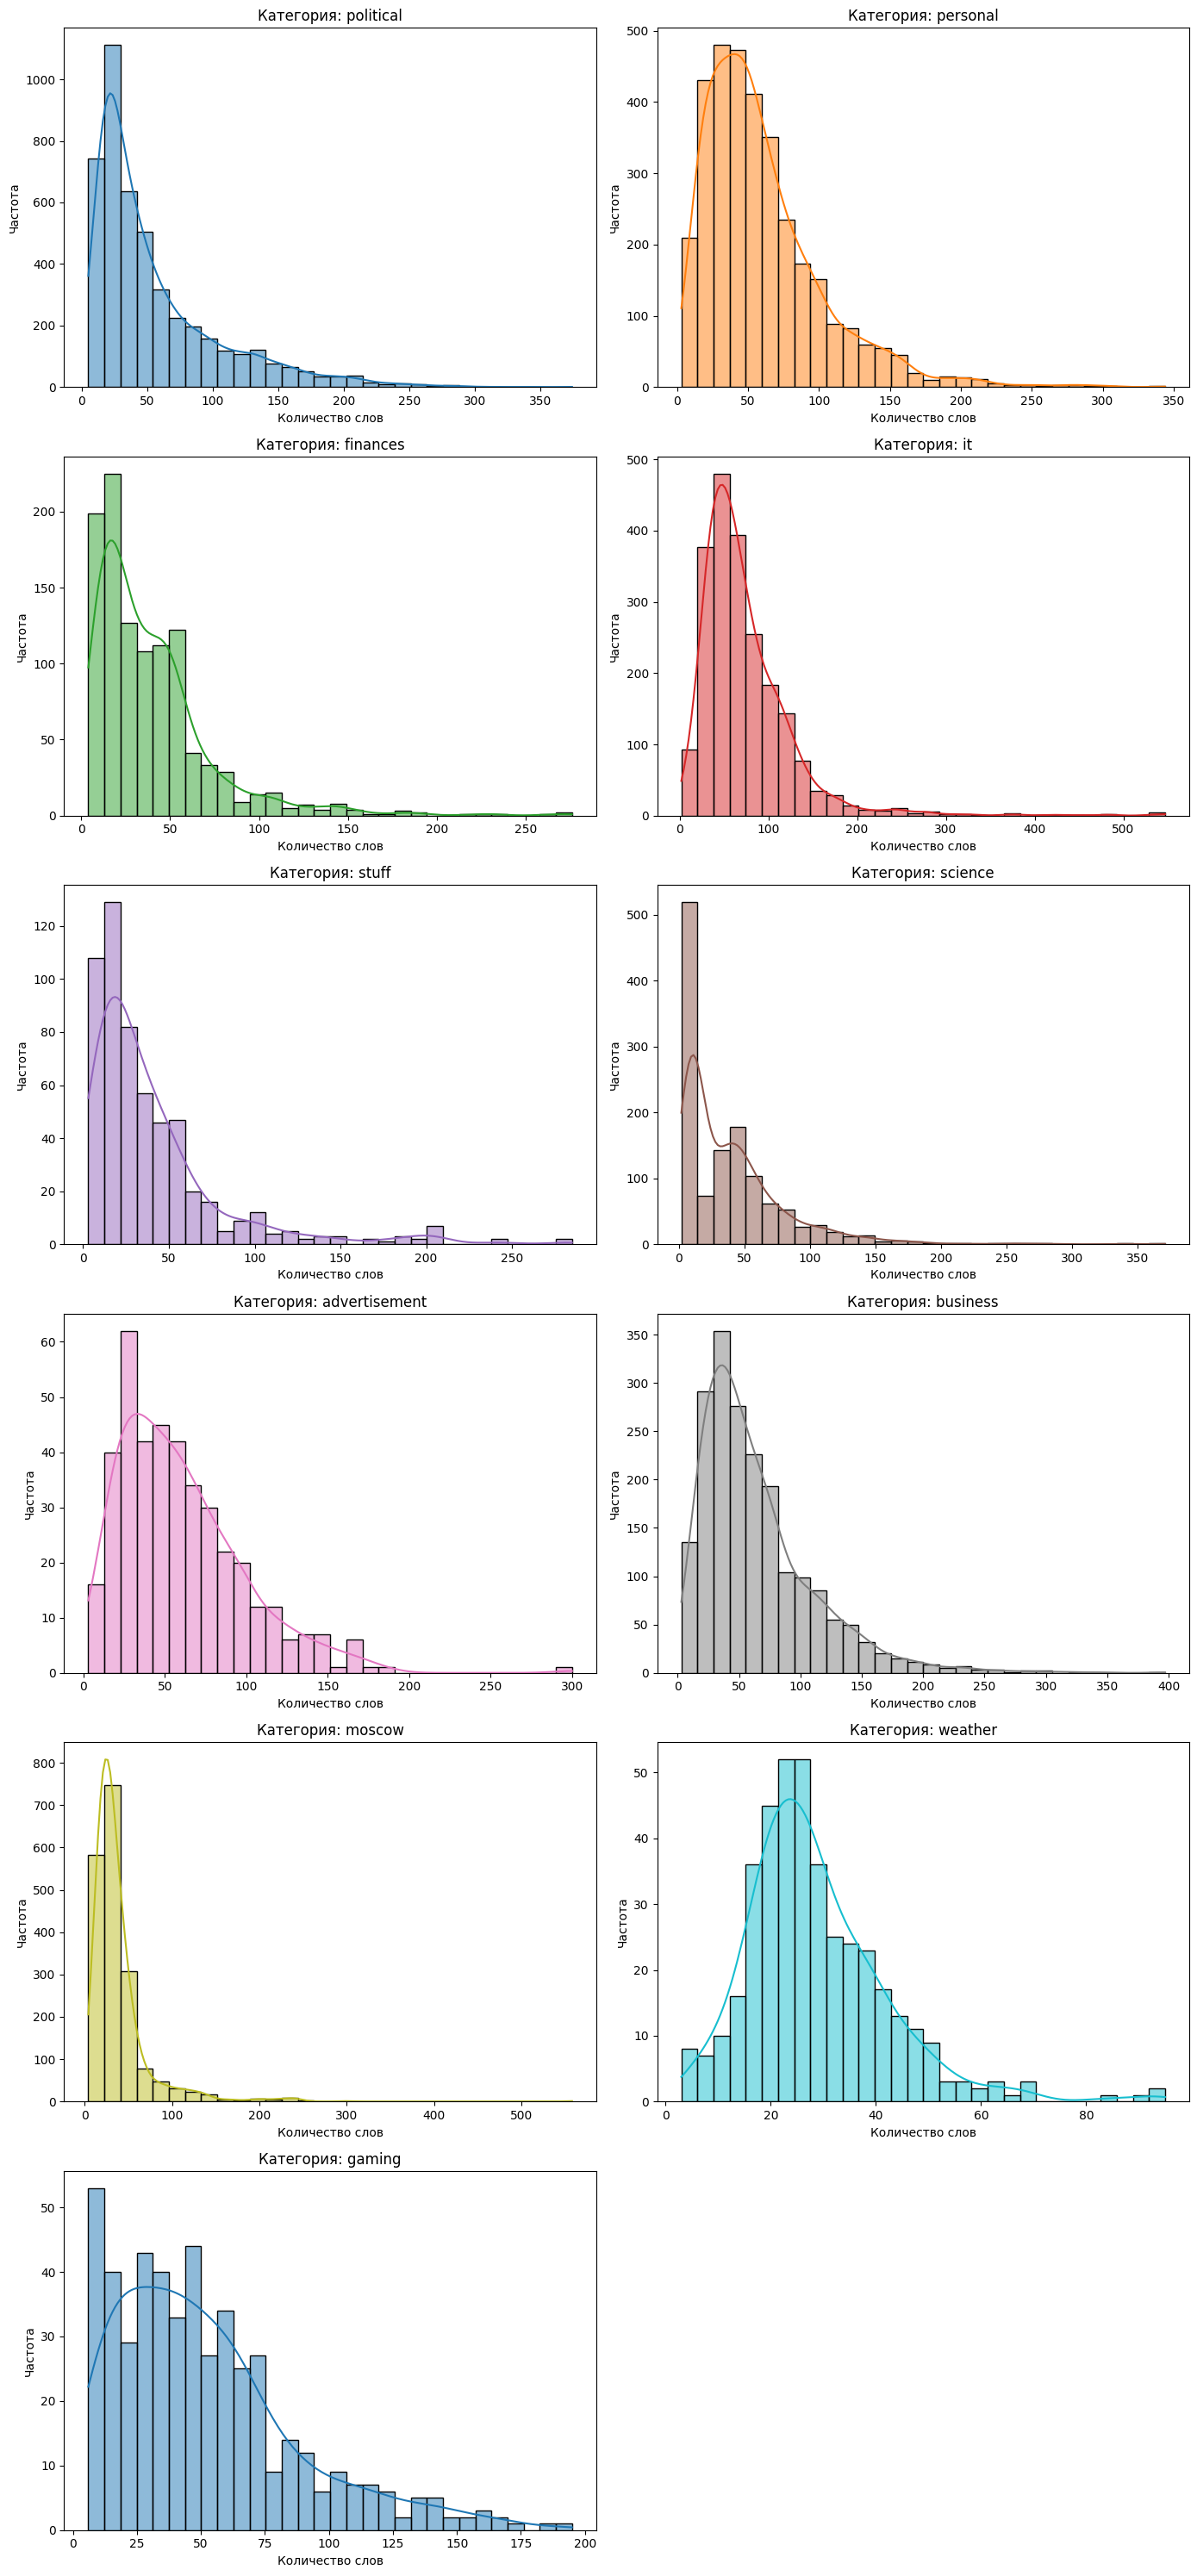

In [45]:
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()
palette = sns.color_palette("tab10", len(categories))

for i, (category, color) in enumerate(zip(categories, palette)):
    ax = axes[i]
    sns.histplot(df[df['category'] == category]['text_length'], bins=30, kde=True, color=color, ax=ax)
    ax.set_title(f'Category: {category}', fontsize=12)
    ax.set_xlabel('Number of words')
    ax.set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Message length differs considerably between categories. **IT** leads with an average of 73.8 words per post, 45% more than the shortest category, "weather" (28.6 words). The medians tell the same story: from 61 words in IT down to 26 words in weather posts.

There is a clear **topical pattern**:
- Technical and professional categories (**IT**, **business**) carry the most detailed messages
- Personal and entertainment topics (**personal**, **gaming**) sit in the middle
- Utilitarian categories (**finances**, **weather**) are the most terse

Two cases deserve attention:
1. **political** — with a mean of 55.8 words it has one of the lowest medians (38 words), which points to a large number of very short messages alongside a few long ones
2. **advertisement** — balanced figures (59.9/52), which suggests a standardized approach to writing commercial messages

The gap between the mean and the median (most visible in "political") indicates outliers — both very long and extremely short messages. That is a reason to look at the length distribution inside each category separately.

### Preprocessing

In [46]:
nltk.download('stopwords')

stop = set(stopwords.words('russian'))
nlp = spacy.load('ru_core_news_sm')

def clean_text_symbols(text: str) -> str:
    text = re.sub(r"(https?://|www\.)\S+|bit\.ly/\S+|t\.co/\S+", "", text)  
    text = re.sub(r"#[\wа-яА-ЯёЁ]+", "", text)  
    text = re.sub(r"@[\wа-яА-ЯёЁ]+", "", text)  
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"(\*\*|__)(.*?)\1", r"\2", text)
    text = re.sub(r"(\*|_)(.*?)\1", r"\2", text)
    text = re.sub(r"~~(.*?)~~", r"\1", text)
    text = re.sub(r"`{1,2}(.*?)`{1,2}", r"\1", text)
    text = re.sub(r"#{1,6}\s*", "", text)
    text = re.sub(r"\[(.*?)\]\(.*?\)", r"\1", text)
    text = re.sub(r"!\[.*?\]\(.*?\)", "", text)
    text = re.sub(r">\s*", "", text)
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_stop_words(text: str, stop: set) -> str:
    text = " ".join([word for word in text.split() if word not in stop])
    return text

def lemmatize_text(text: str) -> str:
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    return ' '.join(lemmas) 

def preprocess_text(text: str, stop: set) -> str:
    text = text.lower()
    text = clean_text_symbols(text)
    text = lemmatize_text(text)
    text = remove_stop_words(text, stop)
    return text

df['clean_text'] = df['text'].apply(lambda x: preprocess_text(x, stop))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nktkln/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Most channels append a link to their own channel at the end of a post; those lines carry no meaning and are worth removing.

In [47]:
def get_last_text_line(text: str) -> str:
    if len(text.split('\n')) == 1:
        return ""
    return text.strip().split('\n')[-1]

def remove_frequent_last_line(text: str, frequent_lines: list) -> str:
    lines = text.strip().split('\n')
    if len(lines) > 1 and lines[-1] in frequent_lines:
        lines = lines[:-1]
    return '\n'.join(lines).strip()

last_lines_series = df['clean_text'].apply(get_last_text_line)
last_lines_series = last_lines_series.replace("", pd.NA).dropna()
last_line_frequencies = last_lines_series.value_counts()
frequent_last_lines = last_line_frequencies[last_line_frequencies > 1].index.tolist()

df['clean_text'] = df['clean_text'].apply(lambda x: remove_frequent_last_line(x, frequent_last_lines))

The texts went through the standard cleanup:
1. Lowercasing
2. Removal of markup (HTML/Markdown) and special characters
3. Lemmatization and stop-word removal
4. Removal of links (a frequent pattern at the end of a post)

This brings the data into one shape for the NLP analysis that follows, dropping the technical noise without losing meaning. Links got particular attention: removing them in bulk keeps repeated elements from distorting the statistics.

### Top 20 most frequent words

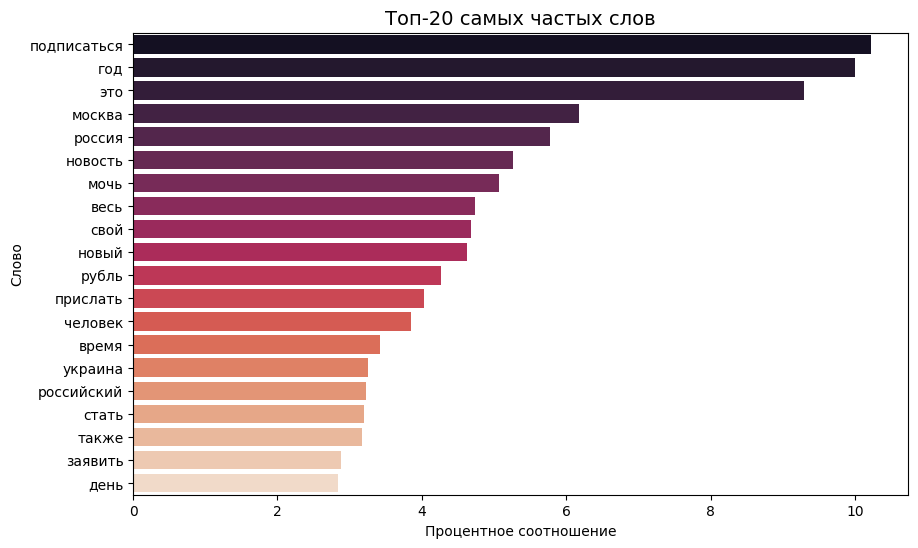

In [48]:
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(20)

total_words = sum([w[1] for w in word_freq])
word_freq_normalized = [(w[0], w[1] / total_words * 100) for w in word_freq]

plt.figure(figsize=(10, 6))
sns.barplot(y=[w[0] for w in word_freq_normalized], x=[w[1] for w in word_freq_normalized], palette='rocket')
plt.title('Top 20 most frequent words', fontsize=14)
plt.xlabel('Share, percent')
plt.ylabel('Word')
plt.show()

With the stop words gone, the frequency analysis brings out the characteristic language patterns.

The most frequent words fall into four groups:

1. Organizational markers ("подписаться", "канал") — boilerplate, to be removed
2. Geographic pointers ("россия", "москва") — local specifics
3. Topical terms ("правительство", "компания") — the main subjects
4. Action verbs ("сообщать", "писать") — typical of the news style

**Next steps:**
- Further cleaning of boilerplate phrases
- Analysis of recurring collocations
- Looking at how words are distributed across categories

In [49]:
stop.update(["это", "также", "подписаться", "который", "изза", "прислать", "ещё", "которые", "топор", "подписывайся", "mash", "shot", "live", "новостную", "кибертопор"])

df['clean_text'] = df['clean_text'].apply(lambda x: remove_stop_words(x, stop))

### Top words per category

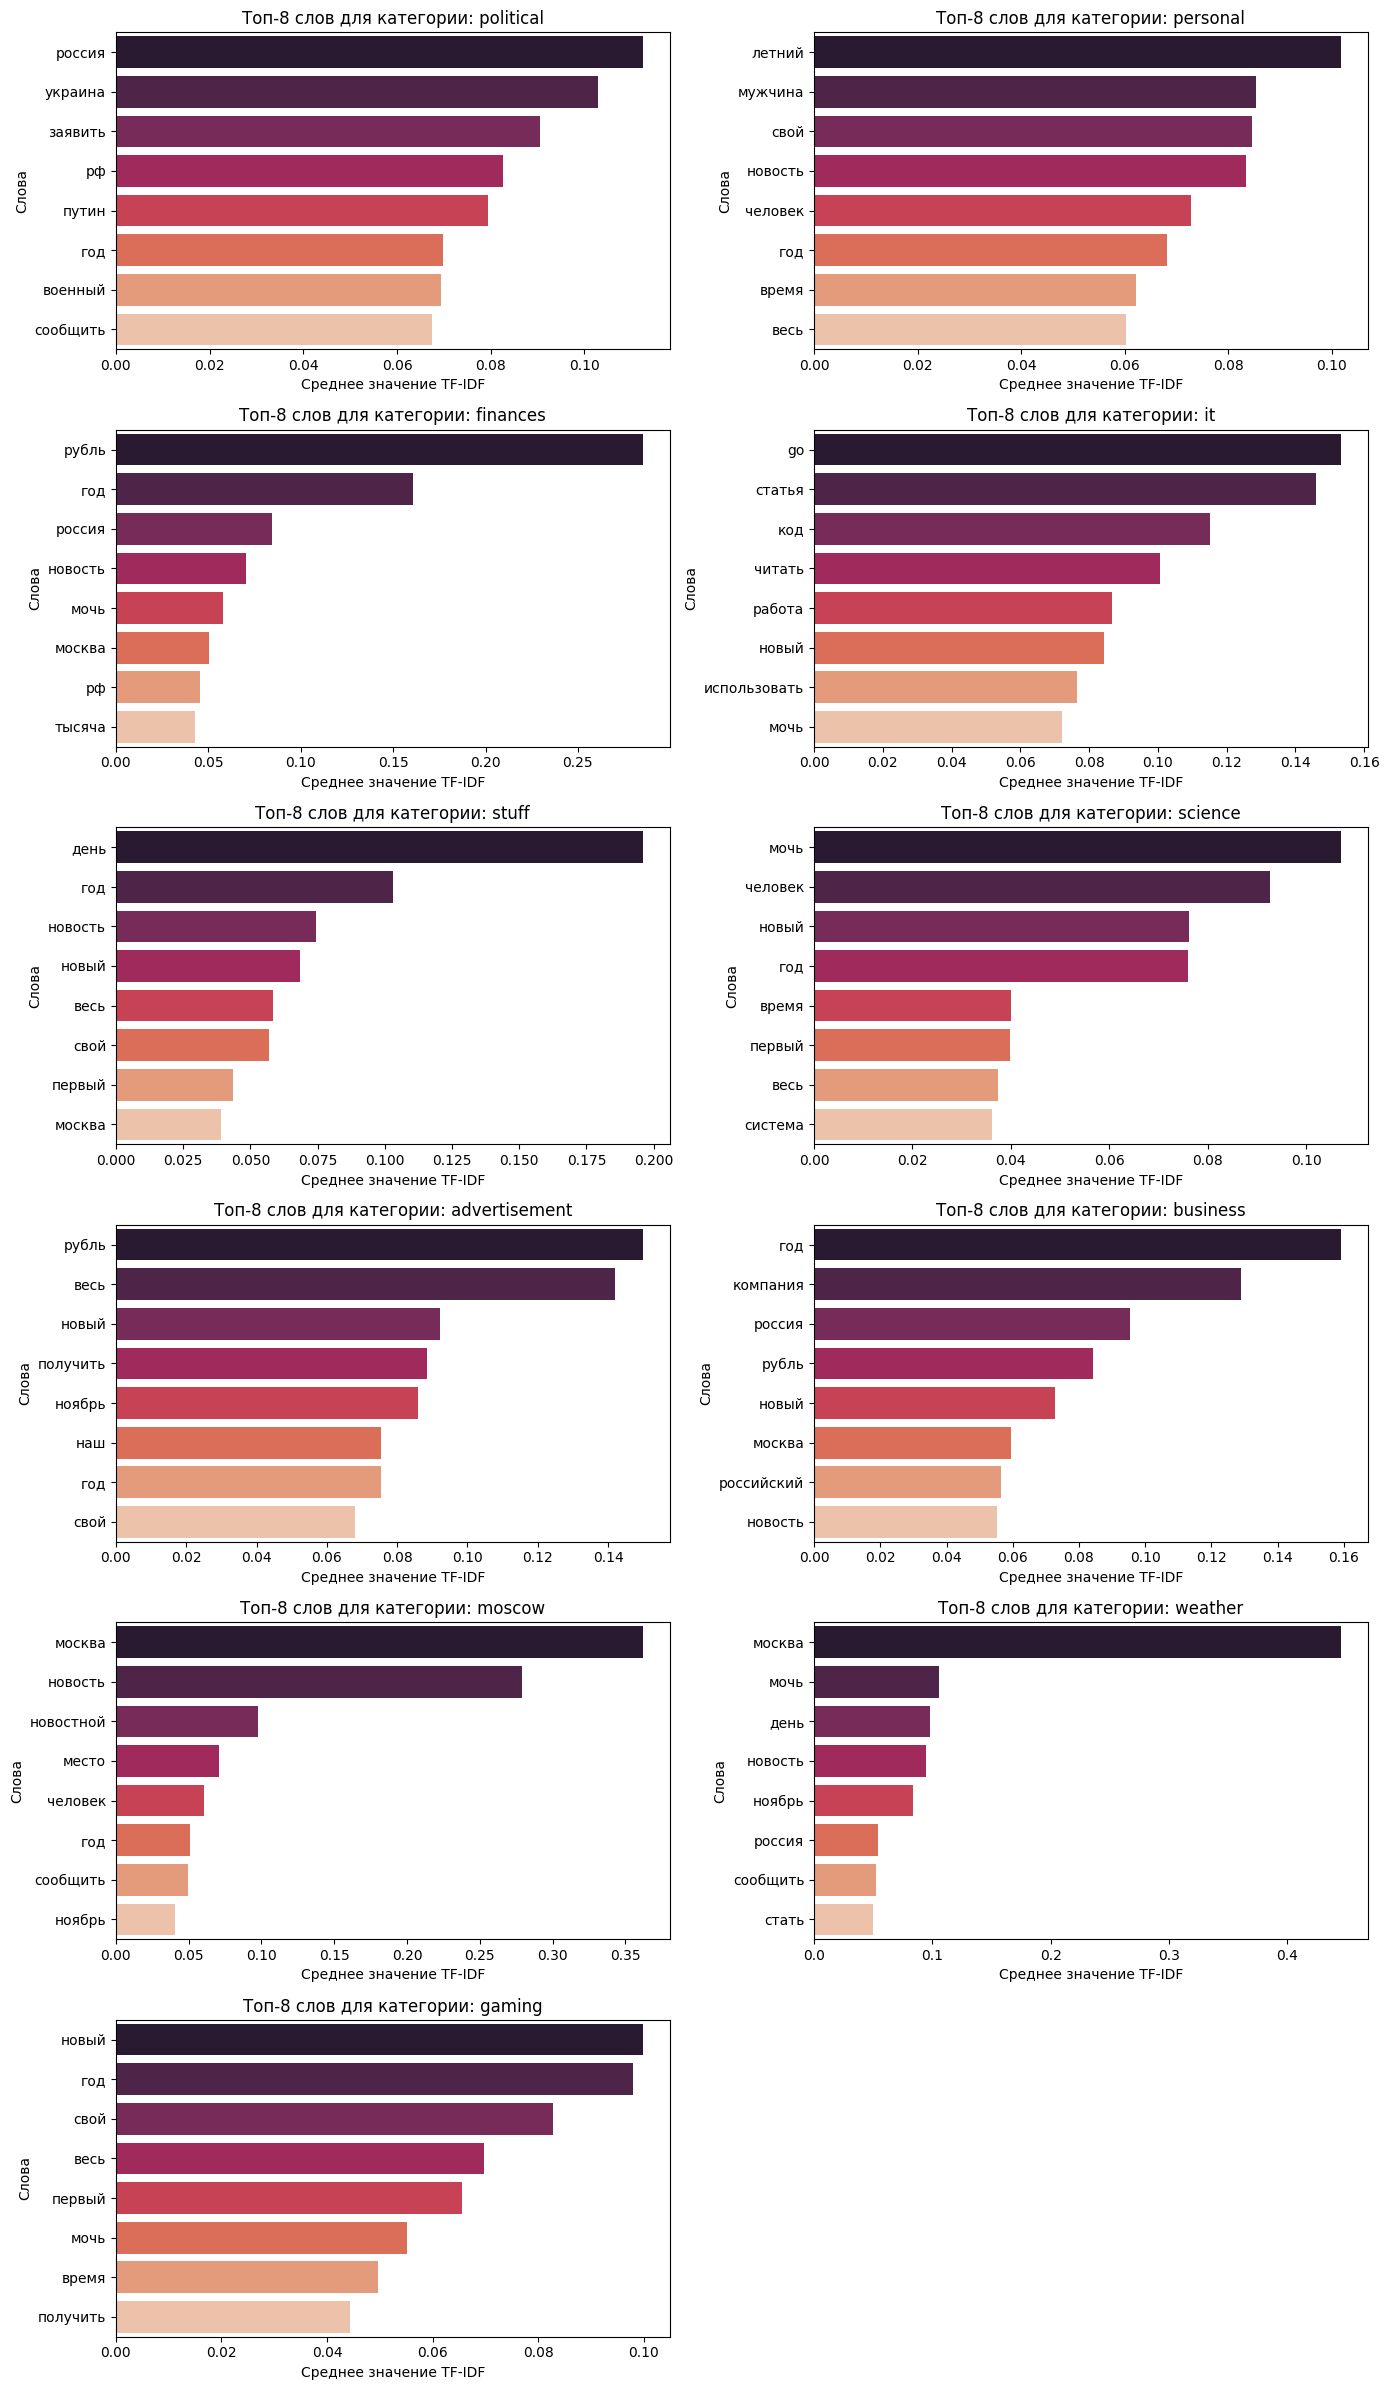

In [50]:
tfidf = TfidfVectorizer(max_features=50)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()
for i, category in enumerate(categories):
    top_words = tfidf_df[df['category'] == category].mean().sort_values(ascending=False).head(8)

    sns.barplot(x=top_words.values, y=top_words.index, ax=axes[i], palette='rocket')
    axes[i].set_title(f"Top 8 words for category: {category}")
    axes[i].set_xlabel('Mean TF-IDF')
    axes[i].set_ylabel('Words')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The top words per category show that "political" is dominated by terms tied to Russia and political events, while "personal" is dominated by words naming people. "finances" mentions money often, and "it" carries technical words such as "python" and "данных". "other" collects words about actions and current events, such as "сегодня" or "человек". Science posts emphasise time and possibility, advertising posts money and dates. Business content stands out with terms about companies and the economy, and posts about Moscow are dominated by geography. Overall each word matches the subject of its category, whether that is politics, finance, technology or something else.

### Bigrams

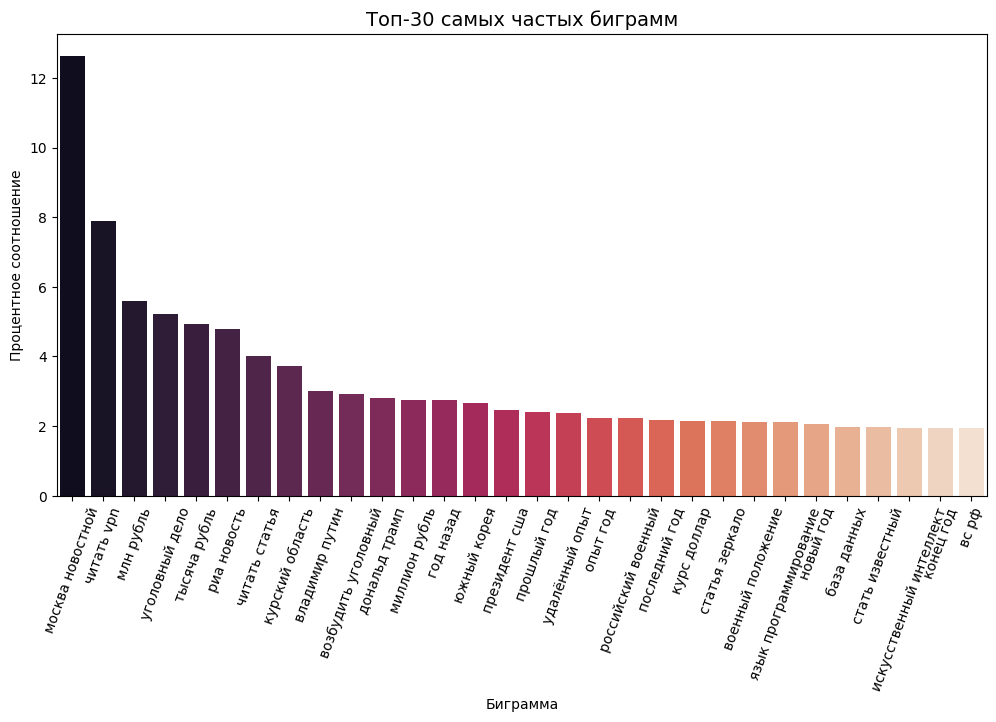

In [51]:
cv2 = CountVectorizer(ngram_range=(2,2), max_features=50)
bigrams = cv2.fit_transform(df['clean_text'])
bigram_freq = pd.DataFrame(bigrams.toarray(), columns=cv2.get_feature_names_out()).sum().sort_values(ascending=False).head(30)
bigram_freq_normalized = bigram_freq / bigram_freq.sum() * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=bigram_freq_normalized.index, y=bigram_freq_normalized.values, palette='rocket')
plt.title('Top 30 most frequent bigrams', fontsize=14)
plt.xlabel('Bigram')
plt.ylabel('Share, percent')
plt.xticks(rotation=70)
plt.show()

The frequent bigrams map clearly onto a few key categories. The financial subject (finances) shows up as "млн рублей", "тыс рублей", "курс доллара", which is what one would expect from that group. News about politics and state bodies (political) is confirmed by "владимир путин", "минобороны рф", "вс рф", and also by "уголовное дело" and "возбуждено уголовное", which can belong to political or to personal when the post is about crime.

The technology side (it, science) comes through in "data science", "читать vpn", "удалённо опыт" — the last of which may also fall into business when the post is about remote work. Mentions of "риа новости" and place names like "курской области" belong more often to political, or to other when the context is unclear.

Advertising bigrams (advertisement) are weakly represented here, but combinations such as "статью зеркало" (links to alternative sources, presumably) or "кликнуть bitly" — had they been present — would point to that category. Entertainment content (stuff) and gaming are essentially absent from the current bigram selection.

**Worth improving:**

- Remove generic phrases like "стало известно", "данный момент": they do not help tell the categories apart.
- Remove bigrams such as "читать статью" and "читать vpn" — some channels use them to attach the original source.

In [52]:
bigrams_to_remove = {
    "стало известно", 
    "данный момент", 
    "читать статью", 
    "читать vpn",
    "риа новости"
}

def remove_bigrams(text: str, bigrams_to_remove: set) -> str:
    for bigram in bigrams_to_remove:
        if bigram in text:
            text = text.replace(bigram, "")
    return text.strip()

df['clean_text'] = df['clean_text'].apply(lambda x: remove_bigrams(x, bigrams_to_remove))

### Publication activity over time

In [53]:
df['weekday'] = df['date'].dt.strftime('%A')
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.day_name()

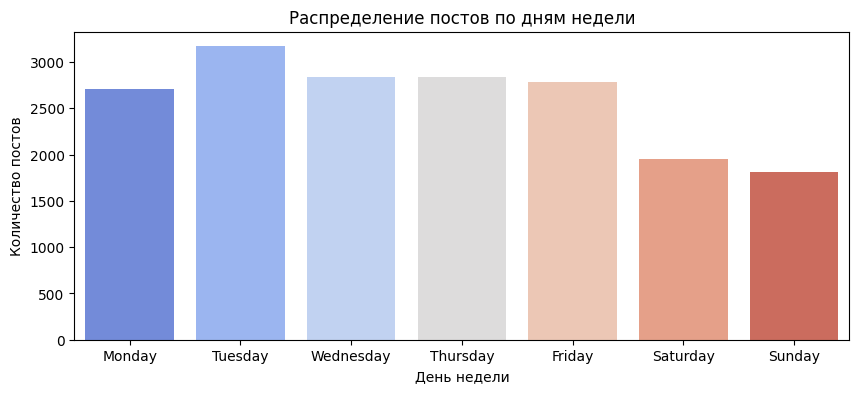

In [54]:
plt.figure(figsize=(10, 4))
sns.countplot(x='weekday', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')
plt.title('Posts per day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number of posts')
plt.show()

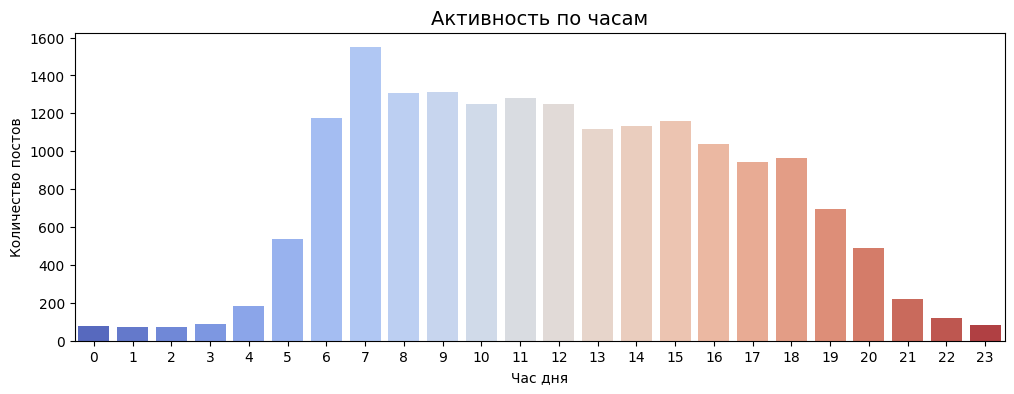

In [55]:
plt.figure(figsize=(12, 4))
sns.countplot(x='hour', data=df, palette='coolwarm')
plt.title('Activity by hour', fontsize=14)
plt.xlabel('Hour of the day')
plt.ylabel('Number of posts')
plt.show()

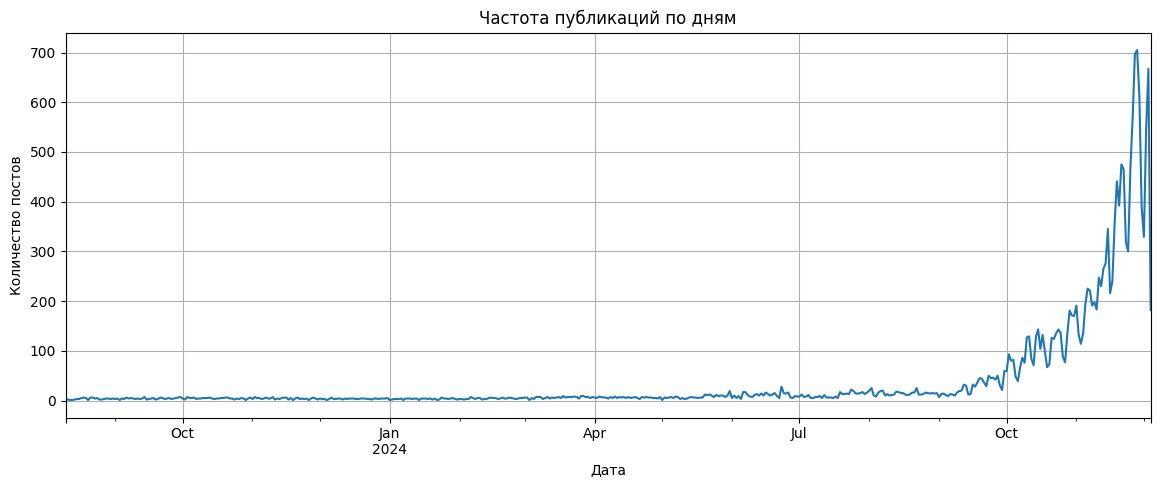

In [56]:
plt.figure(figsize=(14, 5))
df.set_index('date').resample('D').size().plot()
plt.title('Publication frequency per day')
plt.xlabel('Date')
plt.ylabel('Number of posts')
plt.grid(True)
plt.show()

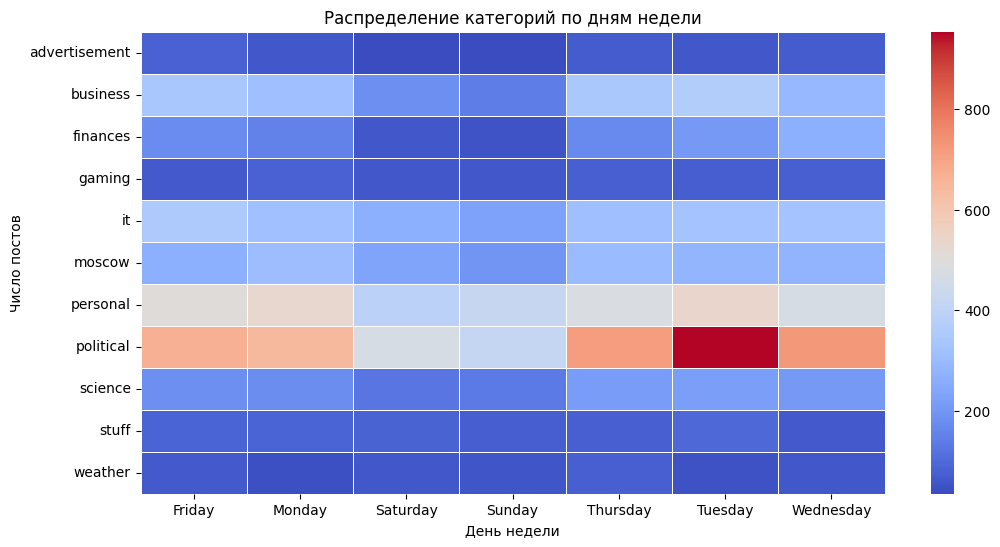

In [57]:
heatmap_data = df.groupby(['weekday', 'hour', 'category']).size().reset_index(name='count')
pivot = heatmap_data.sort_values('weekday').pivot_table(index='category', columns='weekday', values='count', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', linewidths=0.5)
plt.title("Categories by day of the week")
plt.xlabel("Day of the week")
plt.ylabel("Number of posts")
plt.show()

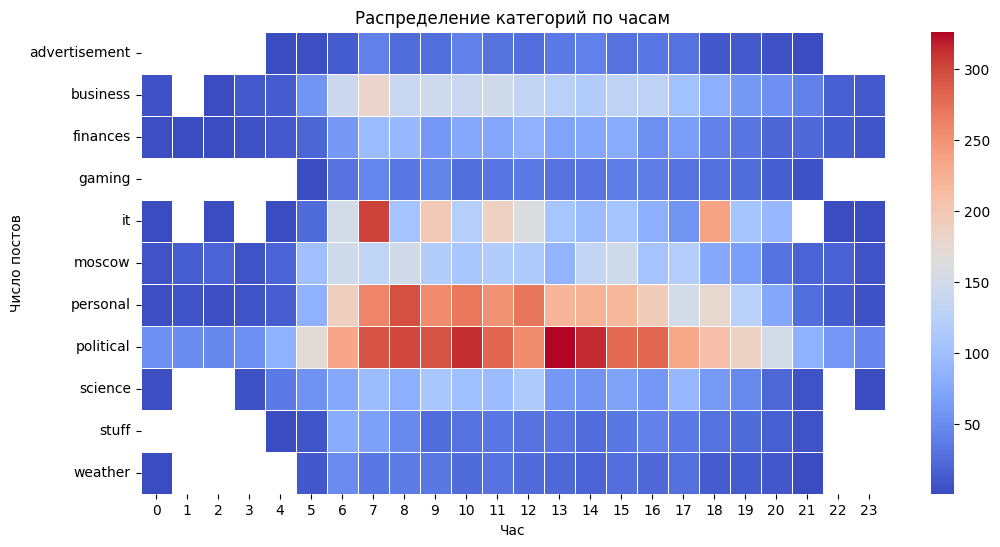

In [58]:
pivot = heatmap_data.pivot_table(index='category', columns='hour', values='count', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', linewidths=0.5)
plt.title("Categories by hour")
plt.xlabel("Hour")
plt.ylabel("Number of posts")
plt.show()

In [59]:
groups = [group['hour'].values for _, group in df.groupby('category')]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {stat:.3f}, p-value: {p:.13f}")

Kruskal-Wallis H-statistic: 40.373, p-value: 0.0000145649856


The posts span October 2023 to October 2024, with the peak of activity in October 2024. Publishing is busiest in the morning and daytime hours (5 to 19), 7 a.m. above all, and most often on Tuesdays. That points at posting aimed at the working week and a morning audience.

The heatmaps and the time plots show that publication time matters for classification: IT content, for example, is posted mostly at 7, 9 and 18, while political news appears between 7 and 10 and between 13 and 14. The day of the week separates the classes far less clearly.

The Kruskal–Wallis test (H=83.238, p≈0.0000) confirms significant differences in how publication times are distributed across categories, which is evidence of different "temporal life patterns" of the content.

### UMAP visualization of the categories

In [60]:
model = SentenceTransformer("DeepPavlov/rubert-base-cased")

No sentence-transformers model found with name DeepPavlov/rubert-base-cased. Creating a new one with mean pooling.
Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model

/Users/nktkln/Downloads/EDA/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


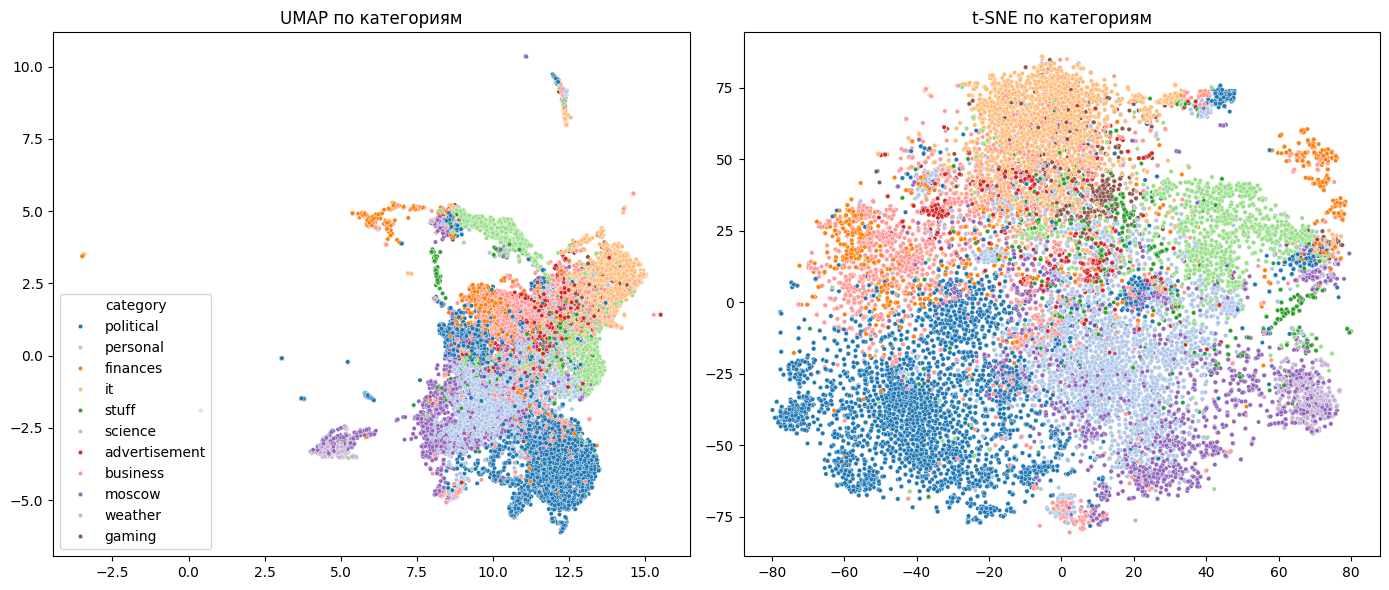

In [61]:
embeddings = model.encode(df['clean_text'].tolist())

umap_model = UMAP(n_components=2, random_state=42)
embeddings_umap = umap_model.fit_transform(embeddings)

tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne = tsne_model.fit_transform(embeddings)


fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=embeddings_umap[:, 0], y=embeddings_umap[:, 1],
                hue=df['category'], palette='tab20', s=10, ax=axs[0])
axs[0].set_title("UMAP by category")

sns.scatterplot(x=embeddings_tsne[:, 0], y=embeddings_tsne[:, 1],
                hue=df['category'], palette='tab20', s=10, ax=axs[1], legend=False)
axs[1].set_title("t-SNE by category")

plt.tight_layout()
plt.show()

UMAP and t-SNE show that the categories separate partially: "political", "science", "personal", "finances" and "business" form distinct clusters, while "weather" and "moscow" blend into each other, which says they are similar. Points of the "other" class sit on the borders of several clusters, which means "other" was used during labelling as the label for posts whose subject is hard to tell. Some outlying points may be anomalies. On the whole the model does capture the differences, but the ambiguous categories need more work, or clearer features.

### TF-IDF baselines against the fine-tuned model

The obvious question about this project is what a cheap linear model scores, and
whether RuBERT earns its cost. To answer that with a number rather than an
argument, two baselines — TF-IDF with logistic regression and TF-IDF with a
linear SVM — are evaluated on exactly the split `model.ipynb` uses for RuBERT:
the same `train_test_split(test_size=0.1, random_state=42, stratify=labels)`,
the same `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`, the same
12 classes, and the same text cleaning the bot applies at runtime.

That last point matters. These cells deliberately use the bot's
`preprocess_text` rather than the lemmatized `clean_text` built earlier in this
notebook, because RuBERT was trained on the former. Giving the baselines a
different input would measure the preprocessing, not the model.


In [ ]:
import re

import numpy as np
import pandas as pd
from colorama import Fore, Style
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

# The cleaning the bot and model.ipynb apply, so the baselines see the same text.
_PATTERNS = (
    (re.compile(r"<.*?>"), ""),
    (re.compile(r"!\[.*?\]\(.*?\)"), ""),
    (re.compile(r"\[(.*?)\]\(.*?\)"), r"\1"),
    (re.compile(r"(\*\*|__)(.*?)\1"), r"\2"),
    (re.compile(r"(\*|_)(.*?)\1"), r"\2"),
    (re.compile(r"~~(.*?)~~"), r"\1"),
    (re.compile(r"`{1,2}(.*?)`{1,2}"), r"\1"),
    (re.compile(r"#{1,6}\s*"), ""),
    (re.compile(r">\s*"), ""),
    (re.compile(r"[^a-zA-Zа-яА-ЯёЁ\s]"), ""),
    (re.compile(r"\s+"), " "),
)


def preprocess_text(text: str) -> str:
    """Apply the same text cleaning used by the Telegram bot."""
    for pattern, replacement in _PATTERNS:
        text = pattern.sub(replacement, text)
    return text.strip().lower()


# The label order model.ipynb fixes, so class ids line up with its report.
UNIQUE_LABELS = [
    "business", "it", "personal", "other", "weather", "gaming",
    "finances", "stuff", "political", "advertisement", "science", "moscow",
]
label_to_id = {label: idx for idx, label in enumerate(UNIQUE_LABELS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

raw_data = pd.read_csv("all_channel_posts.csv")
baseline_texts = raw_data["text"].fillna("").map(preprocess_text).tolist()
baseline_labels = [label_to_id[label] for label in raw_data["category"].tolist()]

train_texts, test_texts, train_labels, test_labels = train_test_split(
    baseline_texts, baseline_labels, test_size=0.1, random_state=42,
    stratify=baseline_labels,
)
train_labels_arr = np.array(train_labels)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{Fore.MAGENTA}train {Style.RESET_ALL}{len(train_texts)}"
      f"{Fore.MAGENTA} / test {Style.RESET_ALL}{len(test_texts)}"
      f"{Fore.MAGENTA} posts, {Style.RESET_ALL}{len(UNIQUE_LABELS)}"
      f"{Fore.MAGENTA} classes{Style.RESET_ALL}\n")

train 19889 / test 2210 posts, 12 classes


In [ ]:
def build_baseline(classifier):
    """Wrap a classifier in the shared TF-IDF pipeline."""
    vectorizer = TfidfVectorizer(
        max_features=50_000, ngram_range=(1, 2), min_df=2, sublinear_tf=True
    )
    return make_pipeline(vectorizer, classifier)


def evaluate_baseline(make_classifier, title):
    """Cross-validate a baseline on RuBERT's folds, then score the test split.

    Args:
        make_classifier: Callable returning a fresh classifier per fit.
        title: Name to print above the results.
    """
    print("=" * 62)
    print(f"{Fore.CYAN}{title}{Style.RESET_ALL}")
    print("=" * 62)

    accuracies, macro_f1s = [], []
    for fold_idx, (train_idx, val_idx) in enumerate(
        kfold.split(train_texts, train_labels_arr), start=1
    ):
        pipeline = build_baseline(make_classifier())
        pipeline.fit([train_texts[i] for i in train_idx], train_labels_arr[train_idx])
        predictions = pipeline.predict([train_texts[i] for i in val_idx])

        accuracy = accuracy_score(train_labels_arr[val_idx], predictions)
        macro_f1 = f1_score(train_labels_arr[val_idx], predictions, average="macro")
        accuracies.append(accuracy)
        macro_f1s.append(macro_f1)
        print(f"{Fore.CYAN}Fold {Style.RESET_ALL}{fold_idx}  "
              f"{Fore.MAGENTA}Validation Accuracy: {Style.RESET_ALL}{accuracy:.4f}   "
              f"{Fore.MAGENTA}Macro F1: {Style.RESET_ALL}{macro_f1:.4f}")

    print(f"\n{Fore.MAGENTA}Mean CV Accuracy: {Style.RESET_ALL}"
          f"{np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
    print(f"{Fore.MAGENTA}Mean CV Macro F1: {Style.RESET_ALL}"
          f"{np.mean(macro_f1s):.4f}")

    # Refit on the whole training split and score the held-out test set once.
    pipeline = build_baseline(make_classifier())
    pipeline.fit(train_texts, train_labels)
    predictions = pipeline.predict(test_texts)
    print(f"\n{Fore.MAGENTA}Test Accuracy: {Style.RESET_ALL}"
          f"{accuracy_score(test_labels, predictions):.4f}")
    print(f"{Fore.MAGENTA}Test Macro F1: {Style.RESET_ALL}"
          f"{f1_score(test_labels, predictions, average='macro'):.4f}")

    present_classes = sorted(set(test_labels))
    print(f"\n{Fore.MAGENTA}Classification Report:{Style.RESET_ALL}")
    print(classification_report(
        test_labels, predictions, labels=present_classes,
        target_names=[id_to_label[idx] for idx in present_classes],
    ))

In [ ]:
evaluate_baseline(
    lambda: LogisticRegression(max_iter=2000, C=5.0, class_weight="balanced"),
    "TF-IDF + LogisticRegression",
)

TF-IDF + LogisticRegression
Fold 1  Validation Accuracy: 0.7333   Macro F1: 0.7181
Fold 2  Validation Accuracy: 0.7293   Macro F1: 0.7168
Fold 3  Validation Accuracy: 0.7267   Macro F1: 0.6936
Fold 4  Validation Accuracy: 0.7305   Macro F1: 0.6995
Fold 5  Validation Accuracy: 0.7433   Macro F1: 0.7213

Mean CV Accuracy: 0.7326 (+/- 0.0057)
Mean CV Macro F1: 0.7099

Test Accuracy: 0.7362
Test Macro F1: 0.7144

Classification Report:
               precision    recall  f1-score   support

     business       0.66      0.59      0.62       203
           it       0.73      0.88      0.80       241
     personal       0.73      0.72      0.73       339
        other       0.57      0.53      0.55       333
      weather       0.73      0.75      0.74        40
       gaming       0.66      0.71      0.69        52
     finances       0.77      0.69      0.73       114
        stuff       0.64      0.59      0.62        61
    political       0.90      0.88      0.89       463
advertisement

In [ ]:
evaluate_baseline(
    lambda: LinearSVC(C=0.5, class_weight="balanced"),
    "TF-IDF + LinearSVC",
)

TF-IDF + LinearSVC
Fold 1  Validation Accuracy: 0.7360   Macro F1: 0.7159
Fold 2  Validation Accuracy: 0.7318   Macro F1: 0.7106
Fold 3  Validation Accuracy: 0.7255   Macro F1: 0.6891
Fold 4  Validation Accuracy: 0.7313   Macro F1: 0.7015
Fold 5  Validation Accuracy: 0.7377   Macro F1: 0.7134

Mean CV Accuracy: 0.7325 (+/- 0.0043)
Mean CV Macro F1: 0.7061

Test Accuracy: 0.7339
Test Macro F1: 0.7069

Classification Report:
               precision    recall  f1-score   support

     business       0.70      0.60      0.64       203
           it       0.72      0.89      0.80       241
     personal       0.71      0.73      0.72       339
        other       0.61      0.47      0.53       333
      weather       0.70      0.75      0.72        40
       gaming       0.64      0.75      0.69        52
     finances       0.76      0.70      0.73       114
        stuff       0.61      0.59      0.60        61
    political       0.89      0.89      0.89       463
advertisement       0.

Both baselines land in the same place, and it is not far below the transformer:

| Model | CV accuracy | CV macro F1 | Test accuracy | Test macro F1 |
| --- | --- | --- | --- | --- |
| TF-IDF + LogisticRegression | 0.7326 ± 0.0057 | 0.7099 | 0.7362 | 0.7144 |
| TF-IDF + LinearSVC | 0.7325 ± 0.0043 | 0.7061 | 0.7339 | 0.7069 |
| RuBERT, fine-tuned | 0.7773 | not recorded | 0.7814 | 0.77 |

RuBERT's figures come from `model.ipynb` — the five fold accuracies 0.7788,
0.7725, 0.7753, 0.7758, 0.7843 and the held-out test report on the same 2,210
posts. Per-fold macro F1 was never printed there, hence the gap in the table.

So fine-tuning buys roughly **4.5 points of accuracy** and **5.6 points of macro
F1** over logistic regression. The two linear models are indistinguishable from
each other (0.7362 against 0.7339), which is the usual outcome once the TF-IDF
features are fixed: the choice of linear head barely matters.

Where the gap sits is the classes that need context rather than keywords —
`other` improves 0.55 → 0.63 F1 and `business` 0.62 → 0.70. The easiest class is
nearly a tie: `political` goes 0.89 → 0.92, because its vocabulary is
unmistakable and TF-IDF finds it just as well.

Two caveats worth stating rather than hiding. The baselines run on the bot's
`preprocess_text`, without the lemmatization and stop-word removal used earlier
in this notebook, which understates them somewhat; and neither had its
hyperparameters searched beyond one sensible setting, while RuBERT got 5 epochs
across 5 folds. A tuned linear model on lemmatized text would likely recover
part of those 4.5 points. That is the honest reading of the table: the
transformer wins, but by a margin a deployment has to weigh against shipping
`torch` and a BERT-sized checkpoint.
